In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.transforms as mtransforms

# Define the target chromosome and the base directory path for the perturbation data
chr = 'allchr'
prefix = f"/path/perturbation/TSS"

   Unnamed: 0 chrom     start       end                    name  distance  \
0       16709  chr1  33311109  33311364  chr1-33311109-33311364      9734   
1       16710  chr1  33311577  33313296  chr1-33311577-33313296      7802   
2       16711  chr1  33313752  33314008  chr1-33313752-33314008      7090   
3       16712  chr1  33314439  33314856  chr1-33314439-33314856      6242   
4       16713  chr1  33315107  33315606  chr1-33315107-33315606      5492   

   mean_delta  se_delta   perturbed_gene  
0    0.000402  0.000100  ENSG00000184389  
1    0.001594  0.000409  ENSG00000184389  
2    0.000404  0.000105  ENSG00000184389  
3    0.000439  0.000101  ENSG00000184389  
4    0.000415  0.000083  ENSG00000184389  


/tmp/ipykernel_2136271/1323326649.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.+legend_x_dist, 1.+legend_y_dist),
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


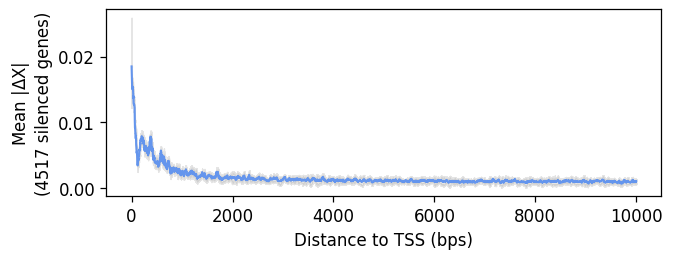

In [ ]:
# Fetch all CSV files in the directory that start with 'TSS_perturb'
outfiles = [os.path.join(prefix, x) for x in os.listdir(prefix) if x.startswith(f'TSS_perturb')]

# Read and concatenate all the individual result files into a single DataFrame
tss_res_df = pd.concat([pd.read_csv(f) for f in outfiles])
print(tss_res_df.head())

# Count the total number of unique genes that were perturbed
n_genes = tss_res_df.perturbed_gene.nunique()

from scipy.stats import t
# Set the window size for calculating rolling statistics
w_size = 200

# Sort values by distance to TSS and calculate the rolling median of 'mean_delta'
rollmean_df = tss_res_df.sort_values('distance').rolling(window=w_size, on='distance', closed='left').median('mean_delta').reset_index()
rollmean_df = rollmean_df.dropna()

# Calculate the rolling standard error of the mean (SEM) for the same window size
rollsd_df = tss_res_df.sort_values('distance').rolling(window=w_size, on='distance', closed='left')['mean_delta'].apply(lambda x: x.sem()).reset_index()
rollsd_df = rollsd_df.dropna()

# Ensure that distance and mean_delta columns are properly typed as numeric
rollmean_df['distance'] = pd.to_numeric(rollmean_df['distance'])
rollmean_df['mean_delta'] = pd.to_numeric(rollmean_df['mean_delta'])
rollsd_df['mean_delta'] = pd.to_numeric(rollsd_df['mean_delta'])

####################################
# Flexible parameters for figure layout
####################################
figure_height = 7
n_cols = 1
n_rows = 1
grid_wspace = 1.5
grid_hspace = 2.5
figure_name = 'fig_template'

####################################
# Fixed figure design settings
####################################
# Set up figure size using centimeters
cm = 1/2.54
fig = plt.figure(figsize=(18*cm, figure_height*cm))
gs = gridspec.GridSpec(n_rows, n_cols)
gs.update(wspace=grid_wspace, hspace=grid_hspace)
ax_list = []

# Configure fonts and general text properties
text_size = 8
scaling_factor = 3
plt.rcParams.update({
    'font.size': 4*scaling_factor, 
    'axes.linewidth': 0.3*scaling_factor,
    'xtick.major.size': 1.5*scaling_factor, 
    'xtick.major.width': 0.3*scaling_factor, 
    'ytick.major.size': 1.5*scaling_factor, 
    'ytick.major.width': 0.3*scaling_factor
})

# Configurations for grid letters (A, B, C, etc.)
grid_letter_positions = [-0.1, 0.05]
grid_letter_fontsize = 8
grid_letter_fontfamily = 'sans-serif'
grid_letter_fontweight = 'bold'
point_size = 1

# Define color palettes for plotting
palette_2colrs = ['palegoldenrod', 'cornflowerblue']
batch_palette = ['palegoldenrod', 'cornflowerblue', 'darkmagenta', 'darkslategray']
palette_3colrs = ["lightgray", "cornflowerblue", "darkmagenta", "darkolivegreen", "firebrick", "midnightblue"]
palette_continuous_1 = "GnBu"
palette_continuous_2 = 'magma_r'

# Legend styling setup
legend_x_dist, legend_y_dist = -0.02, 0.0
handletextpad = 0.1

# Scatter and line plot styling parameters
point_size = 0.3
alpha = 1
point_linewidth = 0.0
handlesize = 0.5
linewidth = 0.5

# Set translation for labeling physical distance
trans = mtransforms.ScaledTranslation(-20/72, 7/72, fig.dpi_scale_trans)

# Apply high DPI and specify figure dimensions for output
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = [9, 4]

# Plot the rolling median line using seaborn
sns.lineplot(data=rollmean_df, x='distance', y='mean_delta', color=palette_2colrs[1], linewidth=1.5)

# Add a shaded confidence interval band around the median line
plt.fill_between(
    rollmean_df['distance'], 
    rollmean_df['mean_delta'] - rollsd_df['mean_delta'], 
    rollmean_df['mean_delta'] + rollsd_df['mean_delta'], 
    alpha=0.2, color='grey'
)

# Configure and position the legend
plt.legend(bbox_to_anchor=(1.+legend_x_dist, 1.+legend_y_dist), 
           loc='upper left', frameon=False,
           handletextpad=handletextpad)

# Set axis labels
plt.xlabel(f"Distance to TSS (bps)")
plt.ylabel("Mean |$\\Delta$X|\n({n_genes} silenced genes)".format(n_genes=n_genes))

# Adjust layout tightly to prevent clipping
plt.tight_layout()

# Save the figure in pdf format
plt.savefig(prefix + f"/IMG_{chr}_TSS_signal.pdf")

# Display the plot
plt.show()